In [1]:
# from numba import njit, prange
import numpy as np
import faiss

data = np.load(f"../data/save/train_test-0-0-0-0.npz")

x = np.array(data["x"], dtype=np.float32)
y = np.array(data["y"], dtype=np.float32)
w = np.array(data["w"], dtype=np.float32)
coor = np.array(data["coor"], dtype=np.int64)

print(x.shape, y.shape, w.shape, coor.shape)

(909278, 108) (909278,) (909278,) (909278, 27, 3)


In [2]:
name_plot = "plot-b3lyp-new"
# exc_over_dm_b3lyp_grids
# exc_over_dm_cc_2_grids
# exc_over_dm_cc_1_j_grids
# exc_over_dm_cc_1_k_grids

In [3]:
(num_sample, dim_sample) = x.shape
res = faiss.StandardGpuResources()
flat_config = faiss.GpuIndexFlatConfig()
flat_config.device = 0
index = faiss.GpuIndexFlatL2(res, dim_sample, flat_config)
index.add(x)

TypeError: in method 'GpuIndexFlat_add', argument 3 of type 'float const *'

In [4]:
b = x.copy()
min_number = 100
distances, indices = index.search(b, min_number)
name = data["name"]

var_y = np.var(np.einsum("ij,i->ij", y[indices], x[:, 0] * w), axis=1)
max_x = 1e-5

mean_of_distances = np.max(distances, axis=1)
mean_of_distances[mean_of_distances < max_x] = -1
mean_of_distances[mean_of_distances > max_x] = 0
mean_of_distances = -mean_of_distances

argsort_ = np.argsort(mean_of_distances * var_y)[::-1][:100]

energy = np.einsum("ij,i->ij", y[indices[argsort_]], (x[:, 0] * w)[argsort_])
distances = distances[argsort_]
name = name[indices[argsort_]]
max_y = np.max(np.abs(energy - energy[:, [0]])) * 627.509
print(max_y)

0.006512758287949509


In [5]:
energy

array([[-3.8362959e-06, -4.1042063e-06, -3.7571162e-06, ...,
        -9.2239907e-06, -4.4932021e-06, -4.5598949e-06],
       [-3.6949468e-06, -3.8937092e-06, -3.6506779e-06, ...,
        -8.2195966e-06, -8.4228568e-06, -8.9957302e-06],
       [-4.1154071e-06, -4.5112542e-06, -4.1624248e-06, ...,
        -4.5615861e-06, -3.6384433e-06, -8.8526267e-06],
       ...,
       [-5.0550889e-06, -4.9833302e-06, -5.1518227e-06, ...,
        -7.9947831e-06, -3.4703432e-06, -7.1891354e-06],
       [-4.6061218e-06, -4.4285821e-06, -4.4132976e-06, ...,
        -7.9796628e-06, -5.4616926e-06, -6.3459129e-06],
       [-2.6419677e-06, -2.7090896e-06, -2.6441087e-06, ...,
        -6.9815974e-06, -4.3537812e-06, -4.5406273e-06]], dtype=float32)

In [5]:
# (sum_of_distances_reverse * var_y)[argsort_]
index_check = 18
print(
    np.sum(
        (x[indices[argsort_[index_check]]] - x[indices[argsort_[index_check]]][0]) ** 2,
        axis=1,
    )
)
print(np.max(distances[index_check]))
print(np.max(np.abs((energy[index_check] - energy[index_check][0]) * 627.509)))
print(name[index_check])

[   0.         64.702034   66.354904  180.31773   181.60168   187.12283
  212.24771   233.48724   255.55658   270.55038   270.7587    276.1231
  365.5378    379.35822   531.75165   546.9693    555.3149    559.9276
  565.2627    578.52734   627.50836   635.9691    653.0638    695.7357
  774.20715   792.90894   811.0049    980.85425  1020.9787   1039.1398
 1102.407    1102.5526   1115.3323   1143.4316   1145.9252   1152.2631
 1158.3416   1163.6322   1169.8634   1176.8378   1221.4648   1231.2577
 1240.3513   1244.4642   1247.3105   1249.3146   1257.11     1288.8838
 1307.2268   1317.9103   1321.3792   1321.6003   1334.0815   1341.5193
 1341.6417   1347.19     1371.6893   1376.706    1381.6987   1399.7703
 1402.0729   1409.7576   1420.0718   1444.907    1446.0436   1459.017
 1465.0432   1471.1313   1482.084    1493.0028   1497.5936   1504.0372
 1518.036    1522.0372   1530.1146   1530.0739   1560.904    1576.9357
 1582.2744   1582.9316   1586.3962   1593.029    1605.8655   1607.1072
 1607.

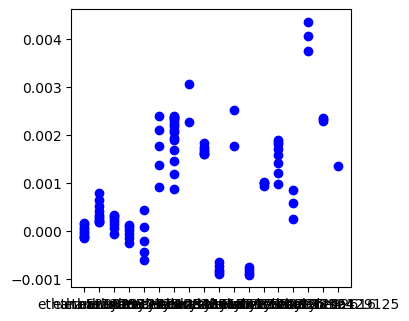

In [6]:
from matplotlib import pyplot as plt

plt.rcParams["figure.figsize"] = np.array([0.5, 0.5]) * 520 / 72
name_energy_dict = {}

for i in range(min_number):
    name_energy_dict[name[index_check][i]] = (
        energy[index_check][i] - energy[index_check][0]
    ) * 627.509


name_dict = {
    "methane": 0,
    "ethane": 1,
    "ethylene": 2,
    "acetylene": 3,
}

x_name_dict = {}
x_energy_dict = {}

for name_i, energy_i in name_energy_dict.items():
    x_ = (
        name_i.split("_")[0]
        + name_i.split("_")[5]
        + name_i.split("_")[6]
        + name_i.split("_")[7]
    )
    if x_ in x_name_dict:
        x_name_dict[x_].append([name_i, energy_i])
    else:
        x_name_dict[x_] = [[name_i, energy_i]]
    plt.scatter(x_, energy_i, c="b")

In [7]:
from pathlib import Path

Path(f"{name_plot}-{max_x}/plot/").mkdir(parents=True, exist_ok=True)

for key_, value_ in x_name_dict.items():
    for j in value_:
        plt.scatter(float(j[0].split("_")[4]), j[1], c="r")
    plt.xticks(rotation=90)
    plt.xlabel(r"$\Delta$ x ($\AA$)")
    plt.ylabel("Energy (kcal/mol)")
    plt.xlim(-0.575, 0.575)
    plt.xticks(np.arange(-0.5, 0.6, 0.1))
    plt.savefig(f"{name_plot}-{max_x}/plot/{key_}_{len(value_)}.pdf", bbox_inches="tight")
    plt.savefig(f"{name_plot}-{max_x}/plot/{key_}_{len(value_)}.png", bbox_inches="tight", dpi=300)
    plt.close()
    print(key_, [i[0] for i in value_])

ethane52989 ['ethane_cc-pVDZ_0-1_1_-0.2000_5_29_89', 'ethane_cc-pVDZ_0-1_1_-0.1500_5_29_89', 'ethane_cc-pVDZ_0-1_1_-0.2500_5_29_89', 'ethane_cc-pVDZ_0-1_1_-0.1000_5_29_89', 'ethane_cc-pVDZ_0-1_1_-0.3000_5_29_89', 'ethane_cc-pVDZ_0-1_1_-0.0500_5_29_89', 'ethane_cc-pVDZ_0-1_1_-0.3500_5_29_89', 'ethane_cc-pVDZ_0-1_1_0.0000_5_29_89', 'ethane_cc-pVDZ_0-1_1_-0.4000_5_29_89', 'ethane_cc-pVDZ_0-1_1_0.0500_5_29_89']
ethane72785 ['ethane_cc-pVDZ_0-1_1_0.4500_7_27_85', 'ethane_cc-pVDZ_0-1_1_0.5000_7_27_85', 'ethane_cc-pVDZ_0-1_1_0.4000_7_27_85', 'ethane_cc-pVDZ_0-1_1_0.3500_7_27_85', 'ethane_cc-pVDZ_0-1_1_0.3000_7_27_85', 'ethane_cc-pVDZ_0-1_1_0.2500_7_27_85', 'ethane_cc-pVDZ_0-1_1_0.2000_7_27_85', 'ethane_cc-pVDZ_0-1_1_0.1500_7_27_85', 'ethane_cc-pVDZ_0-1_1_0.1000_7_27_85', 'ethane_cc-pVDZ_0-1_1_0.0500_7_27_85']
ethane029124 ['ethane_cc-pVDZ_0-1_1_-0.4000_0_29_124', 'ethane_cc-pVDZ_0-1_1_-0.4500_0_29_124', 'ethane_cc-pVDZ_0-1_1_-0.3500_0_29_124', 'ethane_cc-pVDZ_0-1_1_-0.5000_0_29_124', 'ethane_

In [8]:
from matplotlib import pyplot as plt

color_dict = {
    "methane": "#004D40",
    "ethane": "#1A237E",
    "ethylene": "#212121",
    "acetylene": "#7B1FA2",
}

plt.rcParams["figure.figsize"] = np.array([0.5, 0.5]) * 520 / 72

f, axes = plt.subplots(1, 1)
axes = np.array(axes).reshape(1, 1)

begin_y = 0.125
end_y = 0.995
int_y = 0.0
begin_x = 0.175
end_x = 0.995
int_x = 0.0
end_x += int_x
end_y += int_y

shapexy = np.shape(axes)
inter_x = np.linspace(begin_x, end_x, shapexy[1] + 1)
inter_y = np.linspace(begin_y, end_y, shapexy[0] + 1)

delta_x = inter_x[1] - inter_x[0] - int_x
delta_y = inter_y[1] - inter_y[0] - int_y

for i in range(shapexy[0]):
    for j in range(shapexy[1]):
        axes[i][j].set_position(
            [
                inter_x[j],
                inter_y[i],
                inter_x[j + 1] - inter_x[j] - int_x,
                inter_y[i + 1] - inter_y[i] - int_y,
            ]
        )
        axes[i][j].xaxis.set_tick_params(
            direction="in", which="both", bottom=True, top=True
        )
        axes[i][j].yaxis.set_tick_params(
            direction="in", which="both", left=True, right=True
        )

        axes[i, j].set_xlim(-max_x * 0.1, max_x * 1.1)
        axes[i, j].set_ylim(-max_y * 1.1, max_y * 1.1)

        if i != 0:
            axes[i, j].set_xticks([])
        else:
            axes[i, j].set_xticks([0, max_x])
            axes[i, j].set_xticklabels([0, max_x])
        # if j != 0:
        #     axes[i][j].set_yticks([])
        # else:
        #     axes[i][j].set_yticks([-0.03, -0.02, -0.01, 0])
        #     axes[i][j].set_yticklabels([-0.03, -0.02, -0.01, 0])
        #     axes[i][j].set_yticks([0, 0.01, 0.02, 0.03])
        #     axes[i][j].set_yticklabels([0, 0.01, 0.02, 0.03])

for j in range(indices.shape[1]):
    axes[0, 0].scatter(
        distances[index_check][j],
        (energy[index_check][j] - energy[index_check][0]) * 627.509,
        c=(color_dict[name[index_check][j].split("_")[0]],),
    )

for i, c in color_dict.items():
    axes[0, 0].scatter([-1], [-1], c=c, label=i)

plt.xlabel("Distance of cube")
plt.ylabel("$\Delta$ Energy (kcal/mol)")
plt.legend()

plt.savefig(f"{name_plot}-{max_x}/sub_test.pdf", dpi=300, bbox_inches="tight")
plt.savefig(f"{name_plot}-{max_x}/sub_test.png", dpi=300, bbox_inches="tight")
plt.clf()

<Figure size 361.111x361.111 with 0 Axes>

In [9]:
from matplotlib import pyplot as plt

color_dict = {
    "methane": "#004D40",
    "ethane": "#1A237E",
    "ethylene": "#212121",
    "acetylene": "#7B1FA2",
}

plt.rcParams["figure.figsize"] = np.array([3, 3]) * 520 / 72

f, axes = plt.subplots(10, 10)
axes = axes.reshape(10, 10)

begin_y = 0.025
end_y = 0.95
int_y = 0.0
begin_x = 0.025
end_x = 0.95
int_x = 0.0
end_x += int_x
end_y += int_y

shapexy = np.shape(axes)
inter_x = np.linspace(begin_x, end_x, shapexy[1] + 1)
inter_y = np.linspace(begin_y, end_y, shapexy[0] + 1)

delta_x = inter_x[1] - inter_x[0] - int_x
delta_y = inter_y[1] - inter_y[0] - int_y

for i in range(shapexy[0]):
    for j in range(shapexy[1]):
        axes[i][j].set_position(
            [
                inter_x[j],
                inter_y[i],
                inter_x[j + 1] - inter_x[j] - int_x,
                inter_y[i + 1] - inter_y[i] - int_y,
            ]
        )
        axes[i][j].xaxis.set_tick_params(
            direction="in", which="both", bottom=True, top=True
        )
        axes[i][j].yaxis.set_tick_params(
            direction="in", which="both", left=True, right=True
        )

        axes[i, j].set_xlim(-max_x * 0.1, max_x * 1.1)
        # axes[i, j].set_ylim(-0.01, 0.11)
        axes[i, j].set_ylim(-max_y * 0.1, max_y * 1.1)

        if i != 0:
            axes[i, j].set_xticks([])
        else:
            axes[i, j].set_xticks([0, max_x])
            axes[i, j].set_xticklabels([0, max_x])
        if j != 0:
            axes[i][j].set_yticks([])
        # else:
        #     axes[i][j].set_yticks([0, 0.02])
        #     axes[i][j].set_yticklabels([0, 0.02])
        # axes[i][j].set_yticks([0, 0.01, 0.02, 0.03])
        # axes[i][j].set_yticklabels([0, 0.01, 0.02, 0.03])


for i in range(argsort_.shape[0]):
    axes_i, axes_j = np.unravel_index(i, (10, 10))
    for j in range(indices.shape[1]):
        axes[axes_i, axes_j].scatter(
            distances[i][j],
            np.abs(energy[i][j] - energy[i][0]) * 627.509,
            c=(color_dict[name[i][j].split("_")[0]],),
        )

    axes[axes_i, axes_j].text(
        0.01,
        1 - 0.01,
        f"{i}",
        transform=axes[axes_i, axes_j].transAxes,
        va="top",
    )
plt.savefig(f"{name_plot}-{max_x}/test.pdf", dpi=300)
plt.savefig(f"{name_plot}-{max_x}/test.png", dpi=300)
plt.clf()

<Figure size 2166.67x2166.67 with 0 Axes>

In [3]:
energy

NameError: name 'energy' is not defined